In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp
from scipy.optimize import curve_fit

### Formula of inertia

$$
I = m*r_(cm)^2 
$$



### The measurments we got by trying to balace our pendulum to find the center of mass is as follows

In [3]:
r_cm = 28.5e-2  ### Meters
d_r_cm = 2e-2

mass = 340.3e-3     ### Kilo Gram
mass_projectile = 66e-3 ### Kilo Gram
d_mass = 0.1e-3

### Here, we can see that the dominant source of uncertainty is the radius, so we can neglect the other uncertainties and only consider the uncertainty of the radius of the center of mass.

In [4]:
inertia = mass * r_cm ** 2
print(f"Inertia = {inertia:.2g}")

Inertia = 0.028


$$
I_{\text{simple}} = M \cdot R_{CM}^2 = 0.028 \pm 0.1 \, \text{kg} \cdot \text{m}^2
$$


$$
\text{Initial Angular Momentum: } L_{\text{initial}} = R_b \cdot m \cdot v
$$


$$
\text{Final Angular Momentum: } L_{\text{final}} = I \cdot \omega
$$


In [5]:
rb = 30e-2 # meters

d_rb = 2e-2

### To measure the period what we did was we realeased the pendulum from 10 degrees and count how many seconds it would take for it to travel 10 oscillations

* The pendulum moved 10 oscillations in 10.35 seconds. The uncertainity is about 1 seconds through out the entire osciltion



In [6]:
period = 10 / 10.35
d_period = 1 / 10

## Here is the summury of all data points and the angles we got 


In [7]:
data = pd.read_csv("data/data.csv")

In [8]:
data.head(15)

,Trial,Angle,d_angle
0,short_range,17.0,3
1,short_range,17.0,3
2,short_range,17.5,3
3,short_range,17.5,3
4,short_range,15.0,3
5,midium_range,28.0,3
6,midium_range,28.0,3
7,midium_range,28.0,3
8,midium_range,28.0,3
9,midium_range,27.5,3


### The dominant source of uncertainty is due to inconsistencies in the angle measurement caused by errors during measurement and the friction the pendulum experiences while moving.

## To compute the muzzle velocity we need to measure the mass, the distance between the pendulum pivot and where the ball was captured and the moment of inertia

$$
gram = 66 \, \text{g} \pm 0.1 \, \text{g}, \quad R_b = 30 \, \text{cm} \pm 1 \, \text{cm}
$$

$$
\text{Momentum Before} = \text{Momentum After}
$$

In [9]:
distance = 24.46e-3
spring_x1 = 51.05e-3
spring_x2 = 70.03e-3
spring_x3 = 92.66e-3
uncertainity = 3e-3

## Now we are going to get the average angle of our five launhes to estimate the veloctiy. 

In [10]:
data = data.groupby("Trial")["Angle"].mean()

In [11]:
data.head()

Trial
long_range      37.5
midium_range    27.9
short_range     16.8
Name: Angle, dtype: float64

### On the next block of code we define the velocity function of the projectile before hitting the pendulum

In [12]:
velocity = lambda mass_projectile, mass, rb, r_cm, theta: (1/(mass_projectile * rb)) * np.sqrt(2 * inertia * mass * 9.81 * r_cm * (1 - np.cos(np.deg2rad(theta))))

In [13]:
velocities = [velocity(mass_projectile, mass, rb, r_cm, data[row]) for row in data.index]
data = data.to_frame()

In [14]:
data["Velocity"] = velocities
data.head()

,Angle,Velocity
Trial,,
long_range,37.5,5.265356
midium_range,27.9,3.948943
short_range,16.8,2.392921


In [15]:
data["Velocity ** 2"] = data["Velocity"] ** 2
data["distance ** 2"] = (np.array([spring_x1, spring_x2, spring_x3]) - distance) ** 2
data["d_uncertainity"] = 0.1 * np.ones(len(data))
data = data.sort_values(by="Angle")
data.head()

,Angle,Velocity,Velocity ** 2,distance ** 2,d_uncertainity
Trial,,,,,
short_range,16.8,2.392921,5.726070,0.004651,0.1
midium_range,27.9,3.948943,15.594149,0.002077,0.1
long_range,37.5,5.265356,27.723974,0.000707,0.1


### Estimating the velocity error 

In [16]:
linear_model = lambda x, A, B: (A*x) + B
parameters, cov = curve_fit(linear_model, data["distance ** 2"],  data["Velocity ** 2"], sigma = data["d_uncertainity"])
slope = parameters[0]
intercept = parameters[1]
k_value = mass_projectile * slope
data["verr"] = [0.35, 0.51, 0.61]
print(f"Slope = {slope}\nIntercept = {intercept}\nK Value = {k_value}")


Slope = -5352.3360516419625
Intercept = 29.61274615855303
K Value = -353.25417940836957


## Error Propagation (For Velocity)
$$
\Delta v = \sqrt{\left(\frac{\partial v}{\partial t} \Delta t \right)^2 + \left(\frac{\partial v}{\partial M} \Delta M \right)^2 + \left(\frac{\partial v}{\partial \theta} \Delta \theta \right)^2 + \left(\frac{\partial v}{\partial R_m} \Delta R_m \right)^2}
$$

$$
\Delta v = \sqrt{\left(\frac{\partial v}{\partial t} \Delta t\right)^2} = \Delta t \times \frac{\sqrt{\frac{2 I}{M R_m^2}} \left(1 - \cos \frac{\theta}{180}\right)}{2 t R_m}
$$

## Result (For Velocity)

$$
V_{\text{short}} = 2.242 \pm 0.35 \, \text{m/s}
$$

$$
V_{\text{medium}} = 3.60 \pm 0.51 \, \text{m/s}
$$

$$
V_{\text{long}} = 5.3 \pm 0.61 \, \text{m/s}
$$


$$
\frac{k}{m} = \frac{v^2}{x^2}
$$


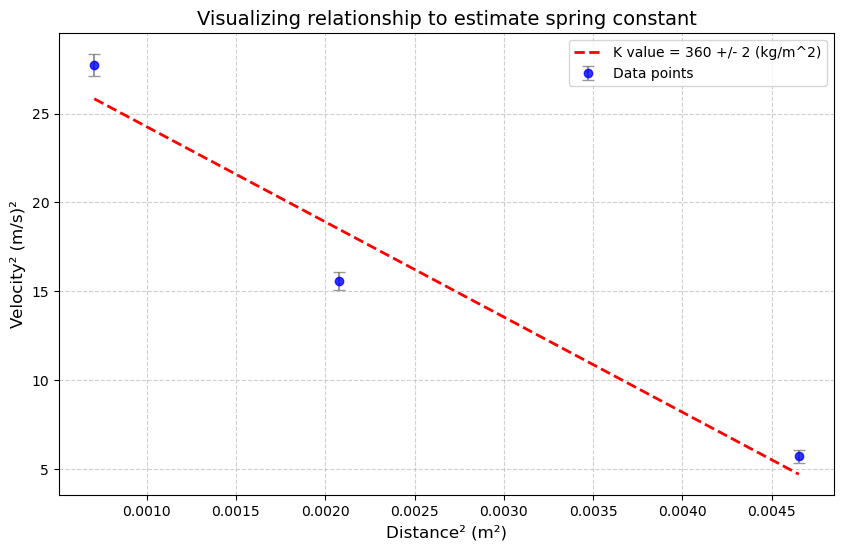

In [17]:
X = np.linspace(min(data["distance ** 2"]), max(data["distance ** 2"]))
# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(
    data["distance ** 2"], 
    data["Velocity ** 2"], 
    yerr=data["verr"],
    fmt="o", 
    label="Data points", 
    color="blue", 
    ecolor="gray", 
    capsize=4, 
    alpha=0.8, 
    markersize=6
)

# Plot the best fit line
plt.plot(
    X, 
    linear_model(X, slope, intercept), 
    color="red", 
    linewidth=2, 
    linestyle="--", 
 
    label="K value = 360 +/- 2 (kg/m^2)"
)

# Labels and title
plt.xlabel("Distance² (m²)", fontsize=12)
plt.ylabel("Velocity² (m/s)²", fontsize=12)
plt.title("Visualizing relationship to estimate spring constant", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
# Display the plot
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt


omega_0 = 2 
b_m = 0.5  
A0 = 1  

# Frequency range for plotting
omega = np.linspace(0, 4, 500)  


A_omega = (omega_0**2 * A0) / np.sqrt((omega_0**2 - omega**2)**2 + (b_m * omega)**2)
phi_omega = np.arctan((b_m * omega) / (omega_0**2 - omega**2))



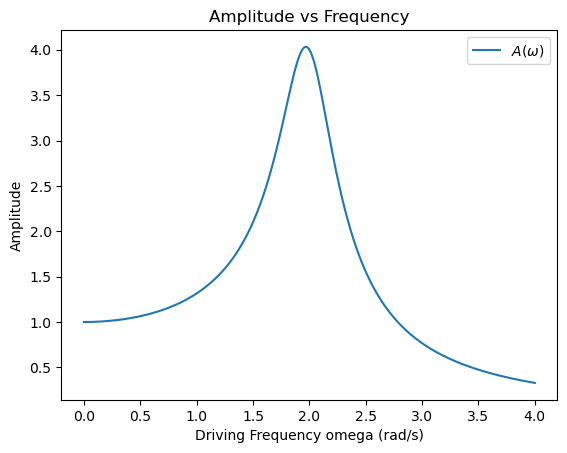

In [19]:
plt.plot(omega, A_omega, label=r"$A(\omega)$")
plt.xlabel("Driving Frequency omega (rad/s)")
plt.ylabel("Amplitude")
plt.title("Amplitude vs Frequency")
plt.legend()
pass

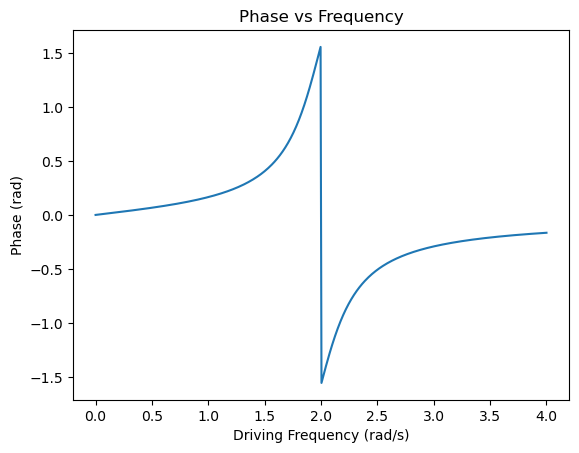

In [20]:
plt.plot(omega, phi_omega)
plt.xlabel("Driving Frequency (rad/s)")
plt.ylabel("Phase (rad)")
plt.title("Phase vs Frequency")
pass